# 07 — Trends & Insights

  Growth analysis and strategic recommendations based on HDBSCAN clustering of 181,294 AI research papers (Jan
  2024 – Feb 2026).

In [14]:
import sys
from pathlib import Path

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.label import load_labels

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "arxiv_clean.csv")
df["published"] = pd.to_datetime(df["published"])
df["month"] = df["published"].dt.to_period("M")


label_info = load_labels(processed_dir / "hdbscan_kalm_labels.json")

# Recreate HDBSCAN labels

kalm_cluster = np.load(processed_dir / "kalm_umap_cluster.npy")
clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=10, metric="euclidean")
hdbscan_labels = clusterer.fit_predict(kalm_cluster)

df["cluster"] = hdbscan_labels
df["cluster_name"] = df["cluster"].map({k: v["label"] for k, v in label_info.items()})
df.loc[df["cluster"] == -1, "cluster_name"] = "Noise"

clustered = df[df["cluster"] != -1].copy()

print(f"Papers: {len(df):,}")
print(f"Clustered: {len(clustered):,}")
print(f"Clusters: {len(label_info)}")

Papers: 181,294
Clustered: 116,952
Clusters: 43


## Monthly Paper Counts per Cluster

In [2]:
monthly_clusters = (
    clustered.groupby(["month", "cluster_name"]).size().unstack(fill_value=0)
)

cluster_sizes = clustered["cluster_name"].value_counts()

print(f"Months: {len(monthly_clusters)}")
print(f"Clusters: {len(monthly_clusters.columns)}")
print("\nTop 10 clusters by size:")
for name, size in cluster_sizes.head(10).items():
    print(f"  {name}: {size:,}")

Months: 26
Clusters: 43

Top 10 clusters by size:
  Robot Planning, Control & Manipulation: 11,451
  Medical AI and Image Segmentation: 10,222
  Multimodal Vision-Language Models and Adaptation: 5,665
  Diffusion Model Advances and Optimization: 4,666
  Multilingual NLP and Speech Processing: 4,571
  Reinforcement Learning Methods and Applications: 3,894
  Federated Learning Privacy and Efficiency: 3,620
  Neural Network Training and Optimization: 3,309
  Remote Sensing and Environmental AI: 3,271
  Transformer Architecture Analysis and Optimization: 3,258


## Growth Analysis — Linear Regression

  For each cluster, fit a linear regression on monthly paper counts. This replaces the naive first-half vs
  last-half comparison with statistical significance (p-values) and goodness of fit (R²).

In [3]:
months = sorted(monthly_clusters.index)
x = np.arange(len(months))

growth_stats = []
for cluster_name in monthly_clusters.columns:
    y = monthly_clusters[cluster_name].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    mean_val = y.mean()
    monthly_growth_pct = (slope / mean_val) * 100 if mean_val > 0 else 0

    growth_stats.append(
        {
            "Cluster": cluster_name,
            "Papers": cluster_sizes.get(cluster_name, 0),
            "Slope": round(slope, 2),
            "Monthly Growth %": round(monthly_growth_pct, 2),
            "R²": round(r_value**2, 4),
            "p-value": round(p_value, 6),
            "Significant": p_value < 0.05,
        }
    )

growth_df = pd.DataFrame(growth_stats).sort_values("Slope", ascending=False)

print(growth_df.to_string(index=False))

                                           Cluster  Papers  Slope  Monthly Growth %     R²  p-value  Significant
                 Medical AI and Image Segmentation   10222  10.19              2.59 0.6489 0.000001         True
                LLM Reasoning Optimization Methods    3193   9.97              8.12 0.6681 0.000000         True
            Robot Planning, Control & Manipulation   11451   9.47              2.15 0.3375 0.001859         True
            LLM Agents and Decision-Making Systems    2285   5.65              6.43 0.7145 0.000000         True
  Multimodal Vision-Language Models and Adaptation    5665   4.79              2.20 0.4909 0.000067         True
              AI Safety and Adversarial Robustness    2885   3.97              3.58 0.4689 0.000114         True
         Diffusion Model Advances and Optimization    4666   3.36              1.87 0.2716 0.006332         True
Transformer Architecture Analysis and Optimization    3258   2.87              2.29 0.2341 0.012

### Growth Chart — Statistically Significant Trends Only

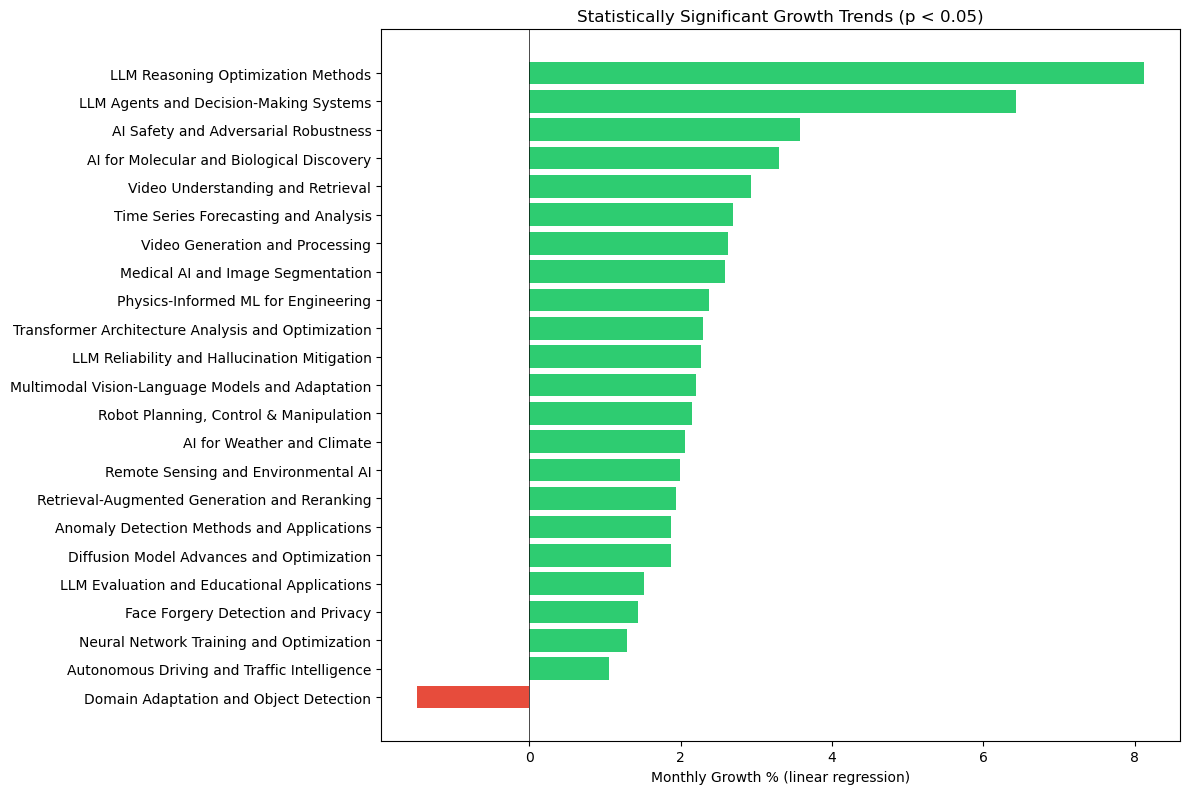

In [5]:
sig = growth_df[growth_df["Significant"]].copy()
sig_sorted = sig.sort_values("Monthly Growth %")

fig, ax = plt.subplots(figsize=(12, max(8, len(sig) * 0.35)))
ax.barh(
    sig_sorted["Cluster"],
    sig_sorted["Monthly Growth %"],
    color=["#2ecc71" if g > 0 else "#e74c3c" for g in sig_sorted["Monthly Growth %"]],
)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Monthly Growth % (linear regression)")
ax.set_title("Statistically Significant Growth Trends (p < 0.05)")
plt.tight_layout()
plt.show()

## Poisson Regression — Share-Based Growth

  Linear regression measures absolute growth. But if ALL of ArXiv is growing, absolute growth is misleading.
  Poisson regression with total monthly volume as an offset measures whether a cluster is growing **relative to
  the overall field** — gaining or losing share.

In [6]:
import statsmodels.api as sm

total_monthly = df.groupby("month").size().values

poisson_results = []
for cluster_name in monthly_clusters.columns:
    y = monthly_clusters[cluster_name].values

    try:
        model = sm.GLM(
            y,
            sm.add_constant(x),
            family=sm.families.Poisson(),
            offset=np.log(total_monthly),
        )
        result = model.fit()

        coef = result.params[1]
        p_val = result.pvalues[1]
        share_growth = (np.exp(coef) - 1) * 100

        poisson_results.append(
            {
                "Cluster": cluster_name,
                "Papers": cluster_sizes.get(cluster_name, 0),
                "Share Growth %/month": round(share_growth, 2),
                "p-value": round(p_val, 6),
                "Significant": p_val < 0.05,
            }
        )
    except Exception as e:
        print(f"  {cluster_name}: failed — {e}")

poisson_df = pd.DataFrame(poisson_results).sort_values(
    "Share Growth %/month", ascending=False
)

print(poisson_df.to_string(index=False))

                                           Cluster  Papers  Share Growth %/month  p-value  Significant
                LLM Reasoning Optimization Methods    3193                  7.72 0.000000         True
            LLM Agents and Decision-Making Systems    2285                  5.45 0.000000         True
              AI Safety and Adversarial Robustness    2885                  2.12 0.000000         True
         AI for Molecular and Biological Discovery    1778                  1.82 0.000000         True
                 Video Understanding and Retrieval    1638                  1.42 0.000031         True
              Time Series Forecasting and Analysis    1772                  1.16 0.000387         True
                   Video Generation and Processing    1152                  1.08 0.007524         True
                 Medical AI and Image Segmentation   10222                  1.06 0.000000         True
               Physics-Informed ML for Engineering    2506               

### Share-Based Growth Chart

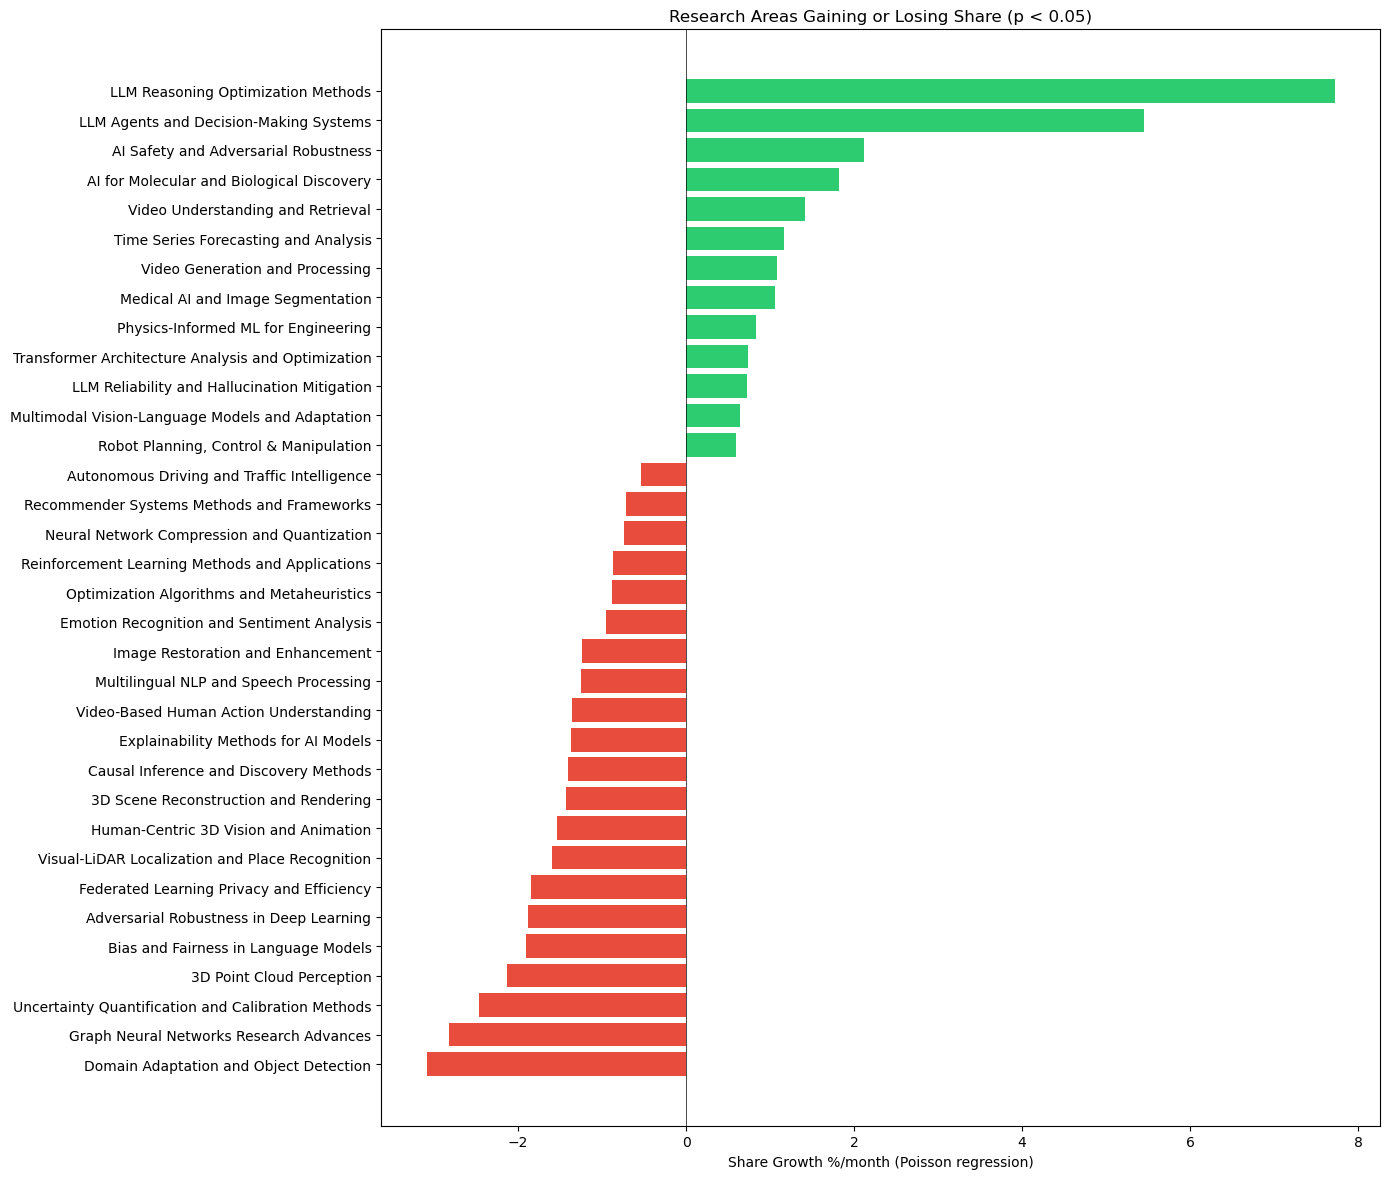

In [8]:
sig_poisson = poisson_df[poisson_df["Significant"]].copy()
sig_sorted = sig_poisson.sort_values("Share Growth %/month")

fig, ax = plt.subplots(figsize=(14, max(8, len(sig_sorted) * 0.35)))
ax.barh(
    sig_sorted["Cluster"],
    sig_sorted["Share Growth %/month"],
    color=[
        "#2ecc71" if g > 0 else "#e74c3c" for g in sig_sorted["Share Growth %/month"]
    ],
)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Share Growth %/month (Poisson regression)")
ax.set_title("Research Areas Gaining or Losing Share (p < 0.05)")
plt.tight_layout()
plt.show()

## Size vs Growth Landscape

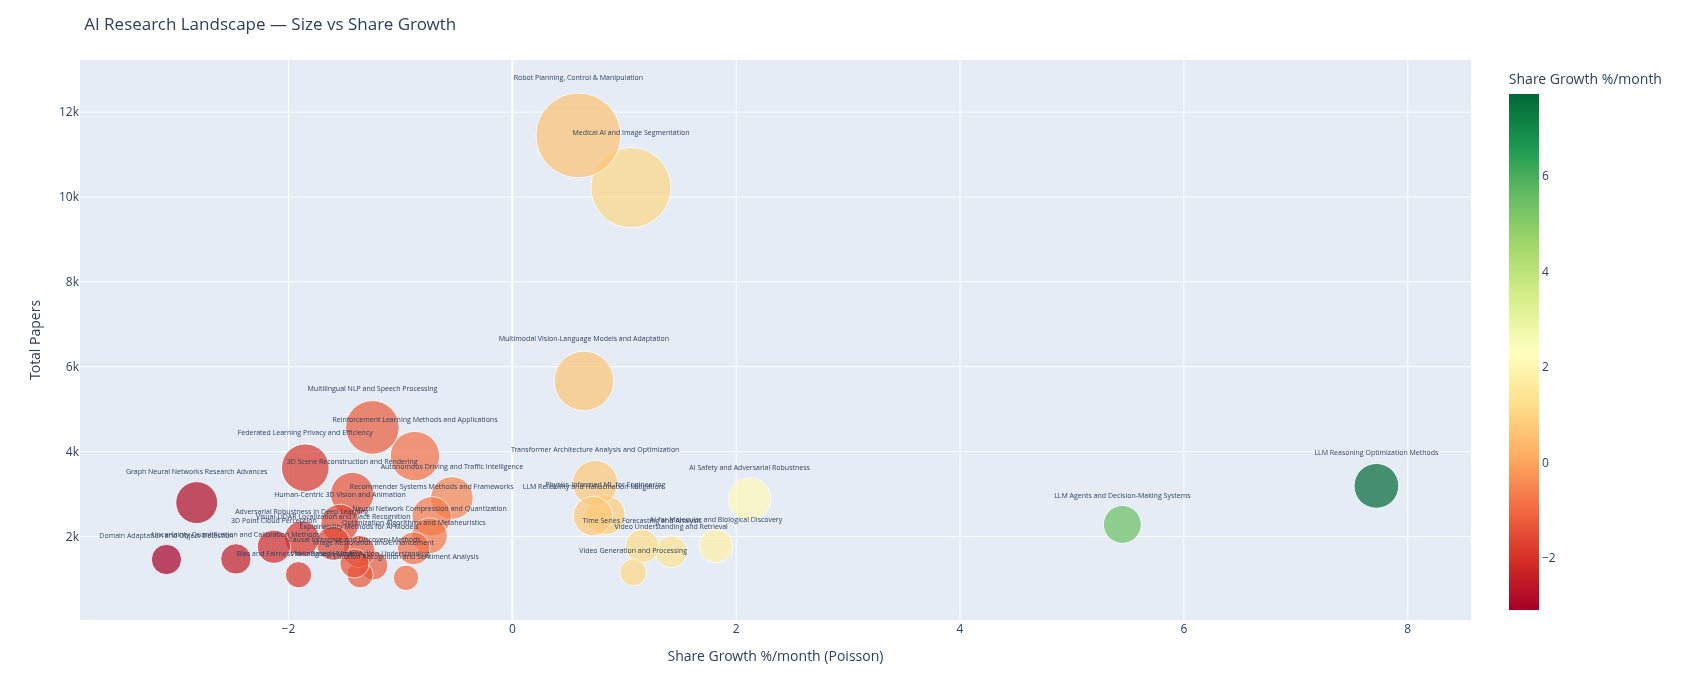

In [10]:
import plotly.express as px

sig_poisson = poisson_df[poisson_df["Significant"]].copy()

fig = px.scatter(
    sig_poisson,
    x="Share Growth %/month",
    y="Papers",
    size="Papers",
    color="Share Growth %/month",
    color_continuous_scale="RdYlGn",
    hover_name="Cluster",
    text="Cluster",
    size_max=60,
)

fig.update_traces(textposition="top center", textfont_size=7)
fig.update_layout(
    title="AI Research Landscape — Size vs Share Growth",
    width=1000,
    height=700,
    xaxis_title="Share Growth %/month (Poisson)",
    yaxis_title="Total Papers",
)
fig.show()

## Strategic Recommendations

  Based on Poisson regression share growth (controlling for overall ArXiv growth) across 181,294 papers from Jan
  2024 – Feb 2026.

In [11]:
growing = poisson_df[
    (poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] > 0)
].sort_values("Share Growth %/month", ascending=False)

declining = poisson_df[
    (poisson_df["Significant"]) & (poisson_df["Share Growth %/month"] < 0)
].sort_values("Share Growth %/month")

print("HIGH PRIORITY — Gaining Share\n")
for _, row in growing.iterrows():
    print(
        f"  {row['Cluster']}"
        f" ({row['Papers']:,} papers,"
        f" +{row['Share Growth %/month']}%/month,"
        f" p={row['p-value']:.6f})"
    )

print("\n\nDECLINING — Losing Share\n")
for _, row in declining.iterrows():
    print(
        f"  {row['Cluster']}"
        f" ({row['Papers']:,} papers,"
        f" {row['Share Growth %/month']}%/month,"
        f" p={row['p-value']:.6f})"
    )

HIGH PRIORITY — Gaining Share

  LLM Reasoning Optimization Methods (3,193 papers, +7.72%/month, p=0.000000)
  LLM Agents and Decision-Making Systems (2,285 papers, +5.45%/month, p=0.000000)
  AI Safety and Adversarial Robustness (2,885 papers, +2.12%/month, p=0.000000)
  AI for Molecular and Biological Discovery (1,778 papers, +1.82%/month, p=0.000000)
  Video Understanding and Retrieval (1,638 papers, +1.42%/month, p=0.000031)
  Time Series Forecasting and Analysis (1,772 papers, +1.16%/month, p=0.000387)
  Video Generation and Processing (1,152 papers, +1.08%/month, p=0.007524)
  Medical AI and Image Segmentation (10,222 papers, +1.06%/month, p=0.000000)
  Physics-Informed ML for Engineering (2,506 papers, +0.83%/month, p=0.002314)
  Transformer Architecture Analysis and Optimization (3,258 papers, +0.74%/month, p=0.002021)
  LLM Reliability and Hallucination Mitigation (2,482 papers, +0.72%/month, p=0.008532)
  Multimodal Vision-Language Models and Adaptation (5,665 papers, +0.64%/

## Summary

  ### Growth Analysis Method
  - **Linear regression** on monthly paper counts for absolute growth trends
  - **Poisson regression** with total monthly volume as offset for share-based growth — controls for overall
  ArXiv growth
  - All reported trends are statistically significant (p < 0.05)

  ### Top Growing Research Areas (gaining share)
  | Cluster | Papers | Share Growth %/month |
  |---------|--------|---------------------|
  | LLM Reasoning Optimization | 3,193 | +7.72% |
  | LLM Agents and Decision-Making | 2,285 | +5.45% |
  | AI Safety and Adversarial Robustness | 2,885 | +2.12% |
  | AI for Molecular and Biological Discovery | 1,778 | +1.82% |
  | Medical AI and Image Segmentation | 10,222 | +1.06% |
  | Robot Planning, Control & Manipulation | 11,451 | +0.59% |

  ### Fastest Declining (losing share)
  | Cluster | Papers | Share Growth %/month |
  |---------|--------|---------------------|
  | Domain Adaptation and Object Detection | 1,458 | -3.09% |
  | Graph Neural Networks | 2,799 | -2.82% |
  | 3D Point Cloud Perception | 1,759 | -2.13% |
  | Bias and Fairness in Language Models | 1,100 | -1.91% |
  | Federated Learning | 3,620 | -1.85% |

  ### Strategic Recommendations
  1. **LLM Reasoning + Agents** — the dominant growth story in AI research. Combined 5,478 papers growing at
  6-8%/month. Partnership priority.
  2. **AI Safety** — growing at 2.1%/month with regulatory pressure (EU AI Act) likely to accelerate this
  further.
  3. **Medical AI + Molecular Discovery** — 12,000 papers, both gaining share. Strong applied-science
  collaboration opportunity.
  4. **Robotics** — largest cluster (11,451 papers) and still gaining share. Established field with steady
  demand.
  5. **Caution areas** — Graph Neural Networks, Federated Learning, and Domain Adaptation are all losing share
  significantly. Avoid new investments unless positioned for contrarian plays.

  ### Key Insight
  13 of 43 clusters are genuinely gaining share. 21 are losing share. The remaining 9 are flat. AI research is
  concentrating — a few hot topics (LLM reasoning, agents, safety) are absorbing attention from many established
  fields.